In [43]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
#%matplotlib widget
%matplotlib inline
import ipywidgets as widgets
from figures import *
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib as mpl
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import json
history_cols = ["Timestamp","Model","OuterFold","InnerFold","HPset","Epoch","TrainLoss","TrainAcc","ValLoss","ValAcc",
		   "AUC","EMA_ValLoss","LR","NoImprove","LrDrop","EsTriggered","BestValLoss","BestEpoch"]

#from matplotlib import colormaps
#list(colormaps)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:

columns = ["Timestamp","Model","OuterFold","InnerFold","HPset","Epoch","TrainLoss","TrainAcc","ValLoss","ValAcc",
		   "AUC","EMA_ValLoss","LR","NoImprove","LrDrop","EsTriggered","BestValLoss","BestEpoch"]

history = pd.read_csv("INNER_epochs.csv", sep=r'\s*,\s*', engine='python')
print(history.columns)

inner_summary = pd.read_csv("INNER_summary.csv", sep=r'\s*,\s*', engine='python')
print(inner_summary.columns)

summary_mean_std = pd.read_csv("INNER_summary_mean_std.csv", sep=r'\s*,\s*', engine='python')
print(summary_mean_std.columns)


Index(['Timestamp', 'Model', 'OuterFold', 'InnerFold', 'HPset', 'Epoch',
       'TrainLoss', 'TrainAcc', 'ValLoss', 'ValAcc', 'AUC', 'EMA_ValLoss',
       'LR', 'NoImprove', 'LrDrop', 'EsTriggered', 'BestValLoss', 'BestEpoch'],
      dtype='object')
Index(['Model', 'OuterFold', 'InnerFold', 'HPset', 'LR', 'WD', 'DR',
       'BestEpoch', 'BestValLoss', 'AUC_at_Best', 'LR_at_Best',
       'ES_Patience_Used', 'RelThresh', 'EMA_alpha', 'ValAcc_at_Best',
       'TrainAcc_at_Best', 'TrainLoss_at_Best', 'Timestamp_at_Best'],
      dtype='object')
Index(['OuterFold', 'LR', 'WD', 'DR', 'ValLoss_mean', 'ValLoss_std',
       'AUC_mean', 'AUC_std', 'LR_mean', 'LR_std', 'ValAcc_mean', 'ValAcc_std',
       'TrainAcc_mean', 'TrainAcc_std', 'TrainLoss_mean', 'TrainLoss_std',
       'n'],
      dtype='object')


In [ ]:

#7: 0.0005, 13: 0.0008
param_map = {1: 0.0002, 7: 0.0005, 13: 0.0008}
outer = 1
HP = ("LR", "WD=1e-6, DR=0.2")
#plot_outer_loss_AUCs(df, param_map=param_map, param_name = HP, use_auc=True, save_path=None)
#plot_inner_loss_AUCs(history, outer_fold=outer, param_map=param_map, param_name=HP, use_ema=True, save_path=None)
plot_inner_loss_AUCs_LRchanges(history, outer_fold=outer, param_map=param_map, param_name=HP, use_ema=False
							   , save_path=None)



{'Model': 'MultiViewCNN', 'OUTER_FOLD': 1, 'INNER_FOLD': 1, 'HPset': 1, 'LR': 0.0002, 'WD': 1e-06, 'DR': 0.2, 'P': 4, 'Epochs': 30, 'trained': True}
{8: 0.2, 10: 0.3, 12: 0.4} ('DR', 'LR=5e-4, WD=1e-4')


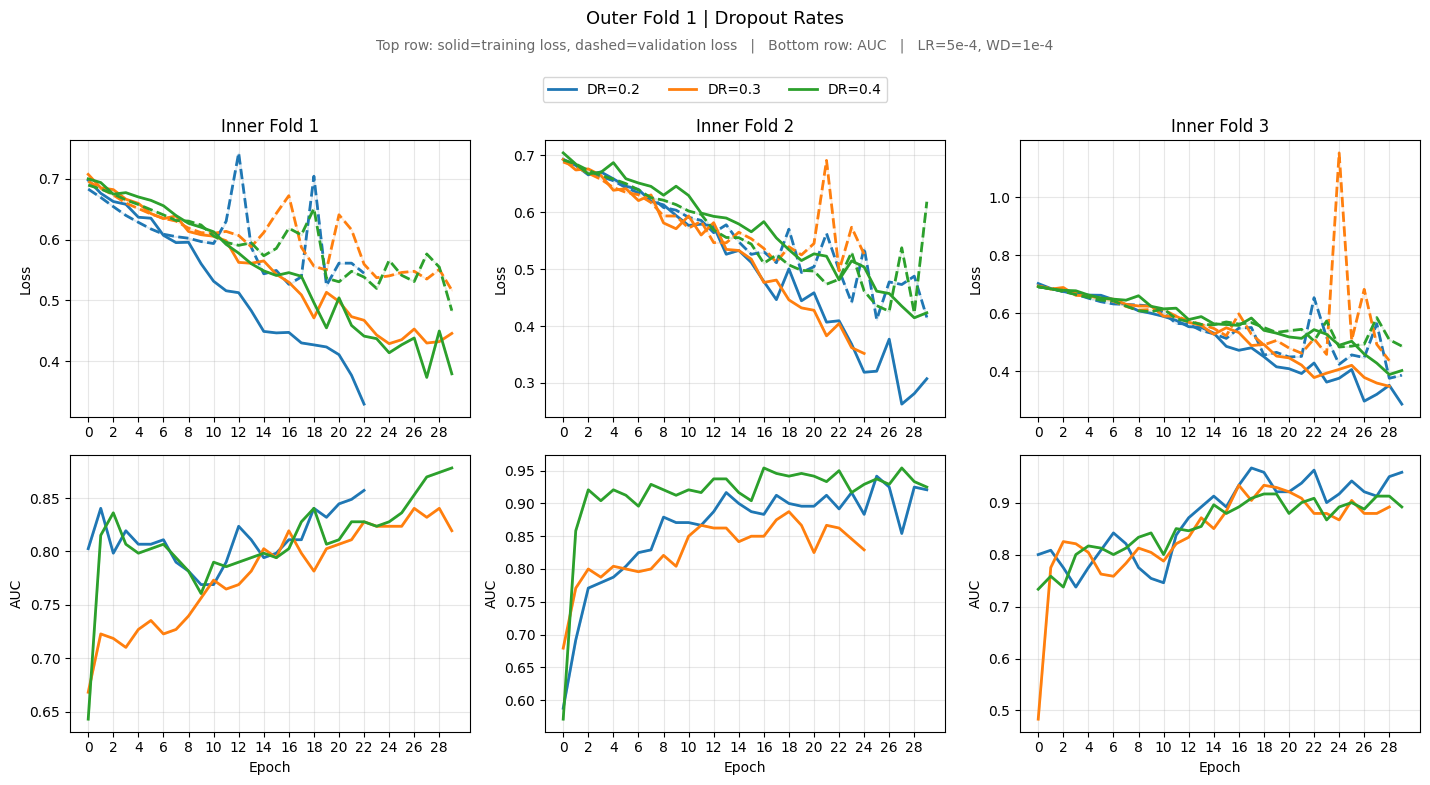

In [5]:
#loss_path =f"figures/O{outer}inners_lss_{HP[0]}.pdf"   # or .png
#acc_path  =f"figures/O{outer}inners_acc_{HP[0]}.pdf"   # or .png
#auc_path  =f"figures/O{outer}inners_auc_{HP[0]}.pdf"   # or .png

#loss_auc_path  =f"figures/O{outer}inners_lss_auc_{HP[0]}.pdf"   # or .png
#plot_inner_loss_AUCs(df, outer_fold=outer, param_map=param_map, param_name = HP, use_ema=False, save_path=loss_auc_path)
with open("INNER_experiments.json", 'r') as f:
	INNER_CV_parameters = json.load(f)
print(INNER_CV_parameters[0])

#param_map = {2: 0.0002, 8: 0.0005, 14: 0.0008}
parameter = "DR"
param_set = [8, 10, 12]
fig_name = f"({param_set[0]}, {param_set[1]}, {param_set[2]})"
param_map = {}
done = 0
hpsets = []
for exp in INNER_CV_parameters:
	if exp['HPset'] in param_set:
		HPset = exp['HPset']
		DR = exp['DR']
		WD = format(exp['WD'], '.0e').replace('e-0','e-').replace('e+0','e+')
		LR = format(exp['LR'], '.0e').replace('e-0','e-').replace('e+0','e+')
		param_map[HPset] = DR
		done += 1
		hpsets.append(HPset)
		#print(exp)
		if done >= len(param_set):
			HP =(f"{parameter}", "LR="+str(LR)+", WD="+str(WD))

			break

print(param_map, HP)
plot_inner_loss_AUCs2(history, outer_fold=1, param_map=param_map, param_name = HP, use_ema=False, save_path=None) #save_path=f"figures/O{1}_{parameter}_({param_set[0]},{param_set[1]},{param_set[2]})_LossAUC.png"
#plot_inner_loss_AUCs(history, outer_fold=2, param_map=param_map, param_name = HP, use_ema=False, save_path=f"figures/O{2}_{parameter}_({param_set[0]},{param_set[1]},{param_set[2]})_LossAUC.png")
#plot_inner_loss_AUCs(history, outer_fold=3, param_map=param_map, param_name = HP, use_ema=False, save_path=f"figures/O{3}_{parameter}_({param_set[0]},{param_set[1]},{param_set[2]})_LossAUC.png")
#plot_inner_loss_AUCs(history, outer_fold=4, param_map=param_map, param_name = HP, use_ema=False, save_path=f"figures/O{4}_{parameter}_({param_set[0]},{param_set[1]},{param_set[2]})_LossAUC.png")



In [ ]:
parameter_sets = [
( 1	, "0.0002"	, "1e-6" , "0.2"),
( 2	, "0.0002"	, "1e-4" , "0.2"),
( 3	, "0.0002"	, "1e-6" , "0.3"),
( 4	, "0.0002"	, "1e-4" , "0.3"),
( 5	, "0.0002"	, "1e-6" , "0.4"),
( 6	, "0.0002"	, "1e-4" , "0.4"),
( 7	, "0.0005"	, "1e-6" , "0.2"),
( 8	, "0.0005"	, "1e-4" , "0.2"),
( 9	, "0.0005"	, "1e-6" , "0.3"),
(10	, "0.0005"	, "1e-4" , "0.3"),
(11	, "0.0005"	, "1e-6" , "0.4"),
(12	, "0.0005"	, "1e-4" , "0.4"),
(13	, "0.0008"	, "1e-6" , "0.2"),
(14	, "0.0008"	, "1e-4" , "0.2"),
(15	, "0.0008"	, "1e-6" , "0.3"),
(16	, "0.0008"	, "1e-4" , "0.3"),
(17	, "0.0008"	, "1e-6" , "0.4"),
(18	, "0.0008"	, "1e-4" , "0.4")]


'''
LR:
2, 8, 14  ---> "1e-4" , "0.2"
1, 7, 13  ---> "1e-6" , "0.2"
4, 10, 16 ---> "1e-4" , "0.3"

DR:
1, 3, 5    ---> "0.0002", "1e-6"
2, 4, 6    ---> "0.0002", "1e-4"
7, 9, 11   ---> "0.0005", "1e-6
8, 10, 12  ---> "0.0005", "1e-4"
13, 15, 17 ---> "0.0008", "1e-6
14, 16, 18 ---> "0.0008", "1e-4"

WD:
1, 2   ---> "0.0002", "0.2"
3, 4   ---> "0.0002", "0.3"
5, 6   ---> "0.0002", "0.4"
7, 8   ---> "0.0005", "0.2"
9, 10  ---> "0.0005", "0.3"
11, 12 ---> "0.0005", "0.4"
13, 14 ---> "0.0008", "0.2"
15, 16 ---> "0.0008", "0.3"
17, 18 ---> "0.0008", "0.4"
'''


In [ ]:

def add_metrics_at_best(df_logs: pd.DataFrame, inner_summary: pd.DataFrame):
	"""
	For each row in inner_summary, fetch metrics from df_logs at its BestEpoch:
	  Adds columns: ValAcc_at_Best, TrainAcc_at_Best, TrainLoss_at_Best, Timestamp_at_Best

	Keys used to join: (OuterFold, InnerFold, HPset, Epoch=BestEpoch)

	df_logs must contain (at least):
	  ['OuterFold','InnerFold','HPset','Epoch','ValAcc','TrainAcc','TrainLoss'] and optionally 'Timestamp'

	inner_summary must contain:
	  ['OuterFold','InnerFold','HPset','BestEpoch']
	"""
	logs = df_logs.copy()
	summ = inner_summary.copy()

	# ---- Coerce dtypes for safety ----
	for c in ["OuterFold", "InnerFold", "HPset", "Epoch"]:
		if c in logs: logs[c] = pd.to_numeric(logs[c], errors="coerce")
	for c in ["ValAcc", "TrainAcc", "TrainLoss"]:
		if c in logs: logs[c] = pd.to_numeric(logs[c], errors="coerce")


	for c in ["OuterFold", "InnerFold", "HPset", "BestEpoch"]:
		if c in summ: summ[c] = pd.to_numeric(summ[c], errors="coerce")

	# ---- Drop rows with missing keys ----
	logs = logs.dropna(subset=["OuterFold","InnerFold","HPset","Epoch"])
	summ = summ.dropna(subset=["OuterFold","InnerFold","HPset","BestEpoch"])

	# ---- Deduplicate logs at the (folds, HPset, epoch) level ----
	key_cols = ["OuterFold","InnerFold","HPset","Epoch"]
	metric_cols = [c for c in ["ValAcc","TrainAcc","TrainLoss","Timestamp"] if c in logs.columns]

	if "Timestamp" in logs.columns and not logs["Timestamp"].isna().all():
		# Keep the last record by Timestamp within each (folds,HPset,epoch)
		logs = logs.sort_values(key_cols + ["Timestamp"])
		logs = logs.drop_duplicates(subset=key_cols, keep="last")
		# No aggregation needed; we now have one row per key
		logs_compact = logs[key_cols + metric_cols]
	else:
		# Aggregate duplicates; take mean for numeric metrics, keep NA for timestamp
		agg_map = {m: "mean" for m in metric_cols if m != "Timestamp"}
		logs_compact = (logs.groupby(key_cols, as_index=False)
							.agg(**{m: (m, agg_map[m]) for m in agg_map}))
		# attach a null Timestamp column so downstream merge has a consistent schema
		if "Timestamp" in metric_cols and "Timestamp" not in logs_compact.columns:
			logs_compact["Timestamp"] = pd.NaT

	# ---- Prepare lookup rows: rename BestEpoch -> Epoch to join on logs ----
	lookups = summ[["OuterFold","InnerFold","HPset","BestEpoch"]].rename(columns={"BestEpoch":"Epoch"})

	# ---- Merge once, then rename outputs ----
	merged = lookups.merge(
		logs_compact,
		on=["OuterFold","InnerFold","HPset","Epoch"],
		how="left",
		validate="m:1"  # each summary row should map to <=1 log row
	).rename(columns={
		"ValAcc":   "ValAcc_at_Best",
		"TrainAcc": "TrainAcc_at_Best",
		"TrainLoss":"TrainLoss_at_Best",
		"Timestamp":"Timestamp_at_Best",
	})

	# ---- Attach back to inner_summary on the original keys ----
	out = summ.merge(
		merged.rename(columns={"Epoch":"BestEpoch"}),
		on=["OuterFold","InnerFold","HPset","BestEpoch"],
		how="left",
		validate="1:1"
	)

	# ---- Sanity report (optional) ----
	miss = out["ValAcc_at_Best"].isna().sum()
	if miss:
		print(f"[add_metrics_at_best] Note: {miss} rows had no matching log record at BestEpoch.")

	return out


In [ ]:
inner_summary = pd.read_csv("INNER_summary.csv", sep=r'\s*,\s*', engine='python')
print(inner_summary.columns)


'''
#group_cols=["OuterFold", "LR", "WD", "DR"]
#summary = (
#inner_summary.groupby(group_cols)
#		  .agg(
#			ValLoss_mean=("BestValLoss", "mean"),
#			ValLoss_std=("BestValLoss", "std"),
#			AUC_mean=("AUC_at_Best", "mean"),
#			AUC_std=("AUC_at_Best", "std"),
#			LR_mean=("LR_at_Best", "mean"),
#			LR_std=("LR_at_Best", "std"),
#		   	ValAcc_mean=("ValAcc_at_Best", "mean"),
#		   	ValAcc_std=("ValAcc_at_Best", "std"),
#		   	TrainAcc_mean=("TrainAcc_at_Best", "mean"),
#		   	TrainAcc_std=("TrainAcc_at_Best", "std"),
#		   	TrainLoss_mean=("TrainLoss_at_Best", "mean"),
#		   	TrainLoss_std=("TrainLoss_at_Best", "std"),
#			  n=("BestValLoss", "count")
#		  )
#		  .reset_index()
#	)
#summary.to_csv('INNER_summary_mean_std.csv', index=False)

'''


Index(['Model', 'OuterFold', 'InnerFold', 'HPset', 'LR', 'WD', 'DR',
       'BestEpoch', 'BestValLoss', 'AUC_at_Best', 'LR_at_Best',
       'ES_Patience_Used', 'RelThresh', 'EMA_alpha', 'ValAcc_at_Best',
       'TrainAcc_at_Best', 'TrainLoss_at_Best', 'Timestamp_at_Best'],
      dtype='object')


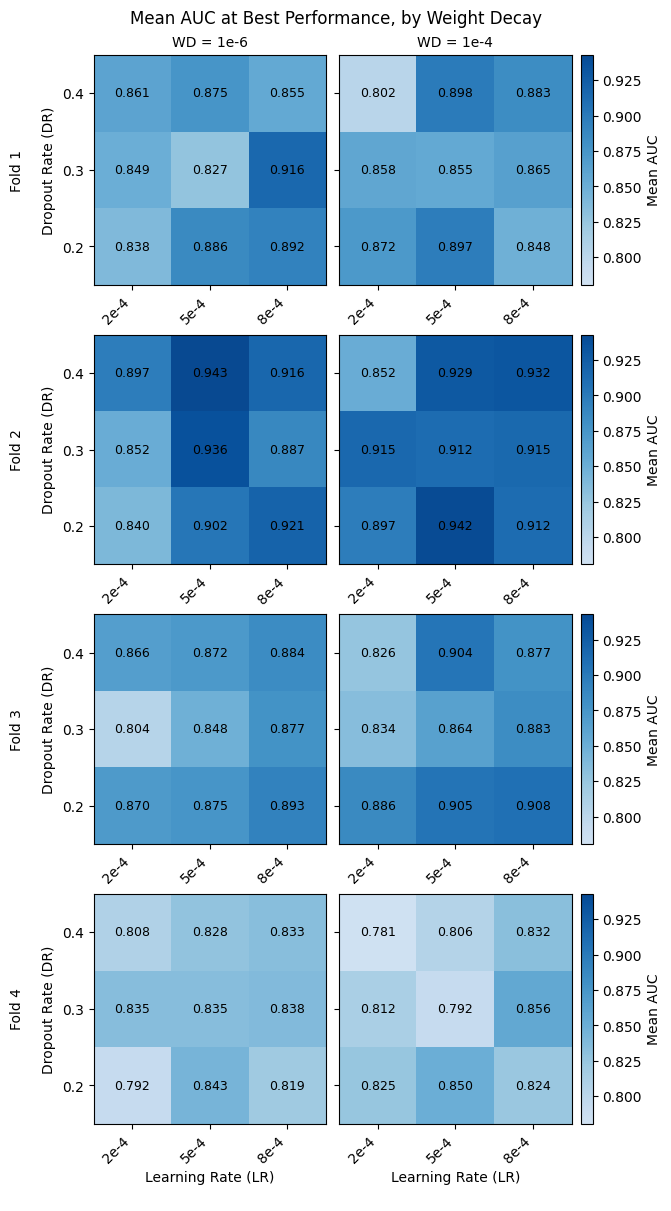

In [24]:

plot_path = f"figures/I_BestAUC_hp_perO.pdf"
facet_heatmap_by_wd_per_OuterFold(inner_summary,
					value="AUC_at_Best",     # or "ValAcc_at_Best" or "LR_ratio"
					cmap="Blues",               # soft, readable
					save_path=None
					#save_path=plot_path
					)



In [38]:
history = pd.read_csv("INNER_epochs.csv", sep=r'\s*,\s*', engine='python')
print(history.columns)

inner_summary = pd.read_csv("INNER_summary.csv", sep=r'\s*,\s*', engine='python')
print(inner_summary.columns)

summary_mean_std = pd.read_csv("INNER_summary_mean_std.csv", sep=r'\s*,\s*', engine='python')
print(summary_mean_std.columns)

summary_mean_std


Index(['Timestamp', 'Model', 'OuterFold', 'InnerFold', 'HPset', 'Epoch',
       'TrainLoss', 'TrainAcc', 'ValLoss', 'ValAcc', 'AUC', 'EMA_ValLoss',
       'LR', 'NoImprove', 'LrDrop', 'EsTriggered', 'BestValLoss', 'BestEpoch'],
      dtype='object')
Index(['Model', 'OuterFold', 'InnerFold', 'HPset', 'LR', 'WD', 'DR',
       'BestEpoch', 'BestValLoss', 'AUC_at_Best', 'LR_at_Best',
       'ES_Patience_Used', 'RelThresh', 'EMA_alpha', 'ValAcc_at_Best',
       'TrainAcc_at_Best', 'TrainLoss_at_Best', 'Timestamp_at_Best'],
      dtype='object')
Index(['OuterFold', 'LR', 'WD', 'DR', 'ValLoss_mean', 'ValLoss_std',
       'AUC_mean', 'AUC_std', 'LR_mean', 'LR_std', 'ValAcc_mean', 'ValAcc_std',
       'TrainAcc_mean', 'TrainAcc_std', 'TrainLoss_mean', 'TrainLoss_std',
       'n'],
      dtype='object')


,OuterFold,LR,WD,DR,ValLoss_mean,ValLoss_std,AUC_mean,AUC_std,LR_mean,LR_std,ValAcc_mean,ValAcc_std,TrainAcc_mean,TrainAcc_std,TrainLoss_mean,TrainLoss_std,n
0,1,0.0002,0.000001,0.2,0.550891,0.035143,0.838200,0.078006,0.000200,0.000000,0.741935,0.085347,0.838710,0.016129,0.510107,0.002466,3
1,1,0.0002,0.000001,0.3,0.568494,0.003516,0.849405,0.058257,0.000200,0.000000,0.731183,0.098550,0.795699,0.018624,0.541856,0.013394,3
2,1,0.0002,0.000001,0.4,0.578444,0.019337,0.860621,0.032122,0.000200,0.000000,0.731183,0.018624,0.774194,0.016129,0.558161,0.016378,3
3,1,0.0002,0.000100,0.2,0.541943,0.027098,0.871674,0.062755,0.000133,0.000058,0.806452,0.085347,0.795699,0.049275,0.518379,0.012641,3
4,1,0.0002,0.000100,0.3,0.561451,0.018807,0.857831,0.048644,0.000167,0.000058,0.741935,0.032258,0.801075,0.018624,0.559288,0.018594,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,4,0.0008,0.000001,0.3,0.466312,0.185326,0.837500,0.165359,0.000467,0.000306,0.774194,0.170694,0.913978,0.082768,0.361777,0.179550,3
68,4,0.0008,0.000001,0.4,0.468574,0.168272,0.833333,0.169916,0.000667,0.000231,0.763441,0.165536,0.870968,0.042673,0.398714,0.158809,3
69,4,0.0008,0.000100,0.2,0.472810,0.171648,0.823611,0.165849,0.000467,0.000306,0.774194,0.140610,0.887097,0.085347,0.335109,0.219430,3
70,4,0.0008,0.000100,0.3,0.508513,0.164140,0.855556,0.088028,0.000667,0.000231,0.741935,0.085347,0.763441,0.223684,0.464314,0.211504,3


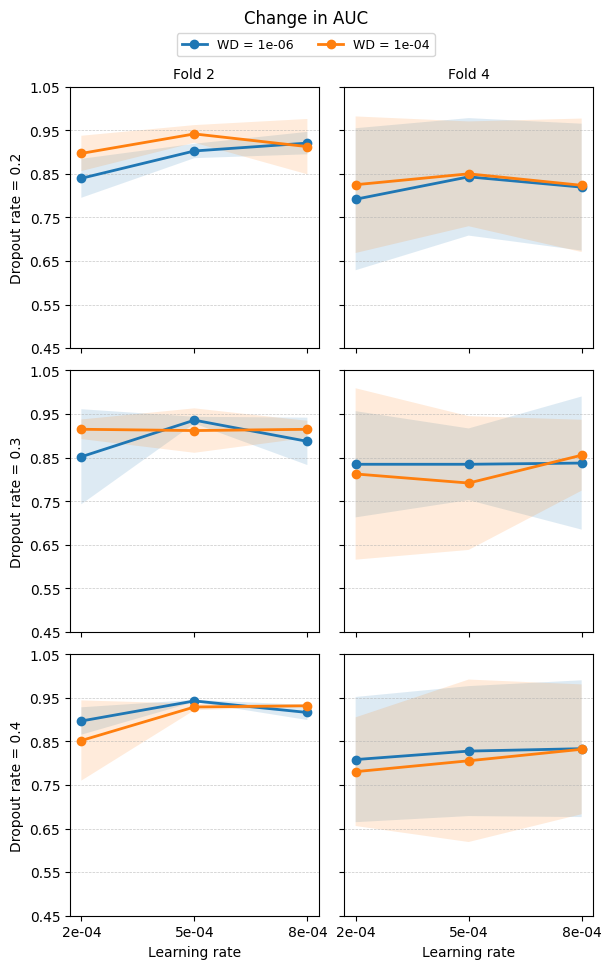

In [118]:
plot_path = f"figures/auc_by_out2-4.pdf" #plot_path = "figures/ValAcc_by_out2-4.pdf"
sub = summary_mean_std.loc[summary_mean_std["OuterFold"].isin([2, 4])]
plot_lr_wd_sweeps_by_dr_and_fold(
    sub,
    metric_base="AUC", # "AUC", "ValLoss", "ValAcc"
    use_ci=True,
	figsize_per_panel  = 3,                     # mean ± std shaded
    #save_path=None
    #save_path=plot_path
)


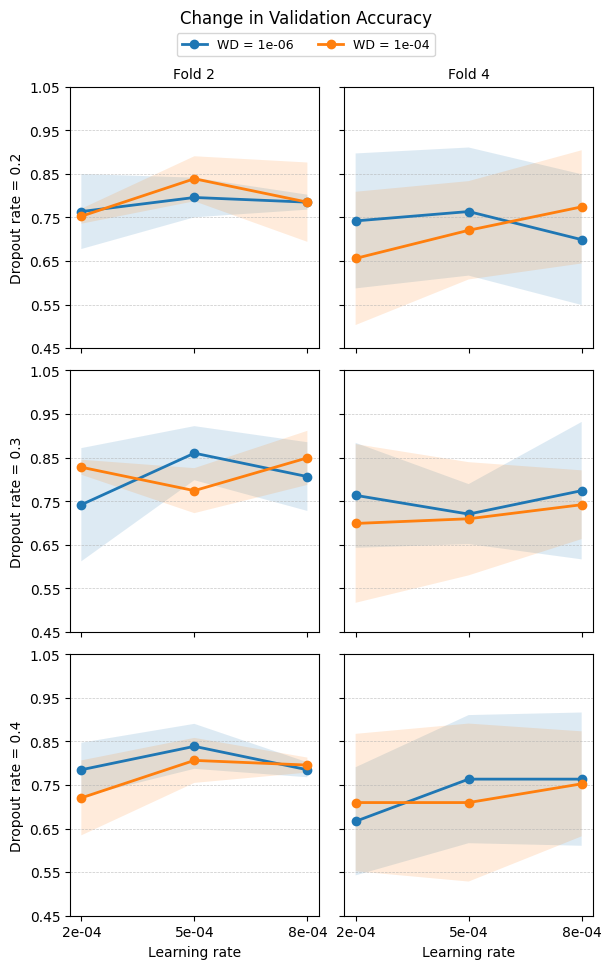

In [116]:
plot_path = "figures/ValAcc_by_out2-4.pdf"
sub = summary_mean_std.loc[summary_mean_std["OuterFold"].isin([2, 4])]
plot_lr_wd_sweeps_by_dr_and_fold(
    sub,
    metric_base="ValAcc", # "AUC", "ValLoss", "ValAcc"
    use_ci=True,
	figsize_per_panel  = 3,                     # mean ± std shaded
    save_path=None
    #save_path=plot_path
)


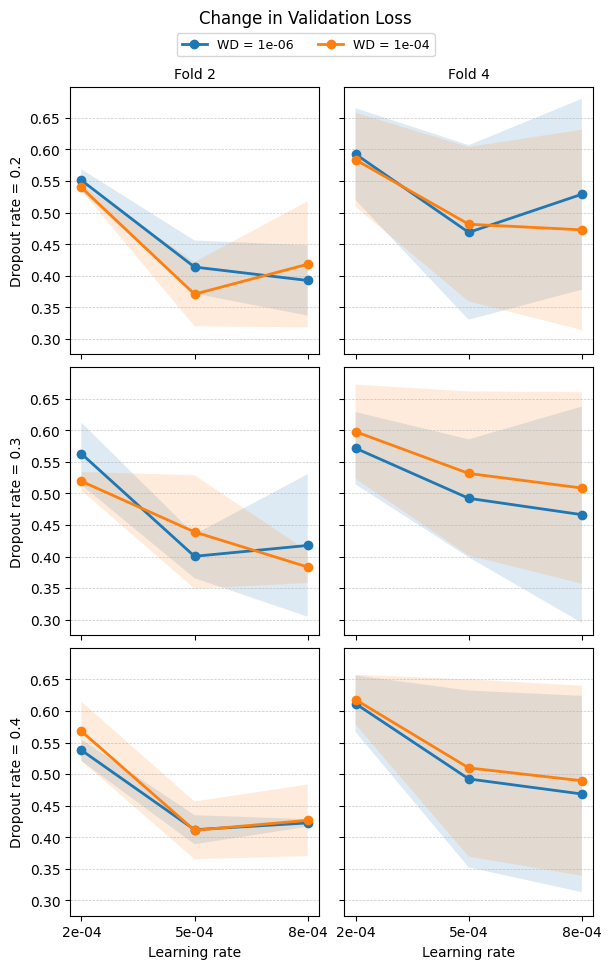

In [120]:
plot_path = f"figures/ValLoss_by_out2-4.pdf"
sub = summary_mean_std.loc[summary_mean_std["OuterFold"].isin([2, 4])]

plot_lr_wd_sweeps_by_dr_and_fold(
    sub,
    metric_base="ValLoss", # "AUC", "ValLoss", "ValAcc"
    use_ci=True,
	figsize_per_panel  = 3,                     # mean ± std shaded
    save_path=None
    #save_path=plot_path
)


In [ ]:
summary_mean_std

metric = 'AUC'
# TrainLoss , ValLoss , TrainAcc , ValAcc , AUC

best_results_idx = summary_mean_std.groupby('OuterFold')[f'{metric}_mean'].idxmax()
best_results_df = summary_mean_std.loc[best_results_idx]
final_table = best_results_df[[
    'OuterFold',
    'LR',
    'WD',
    'DR',
    f'{metric}_mean',
    f'{metric}_std'
]]
final_table = final_table.reset_index(drop=True)

print("--- Best Results per OuterFold ---")
print(final_table)


In [ ]:

best_df = inner_summary[inner_summary["BestValLoss"].notna()]

summary = best_df.groupby("WD")["BestValLoss"].agg(["mean","std"])
summary.plot(y="mean", yerr="std", kind="bar", capsize=4)
plt.ylabel("Best Validation Loss")
plt.title("Best Validation Loss vs Learning Rate")
plt.show()


In [ ]:
characteristics = pd.read_csv("characteristics.csv", sep=r'\s*,\s*', engine='python')
print(characteristics.columns)


In [ ]:
# df is characteristics here ##############
# Functions for mean±std string
def mean_std(series):
	return f"{series.mean():.2f} ± {series.std():.2f}"

# Overall stats
overall_age = mean_std(df["Age"])
tts_age = mean_std(df.loc[df["Label"]==1, "Age"])
normal_age = mean_std(df.loc[df["Label"]==0, "Age"])

# By gender age stats
overall_m_age = mean_std(df.loc[df["Gender"]==0, "Age"])
overall_f_age = mean_std(df.loc[df["Gender"]==1, "Age"])
tts_m_age = mean_std(df.loc[(df["Label"]==1)&(df["Gender"]==0), "Age"])
tts_f_age = mean_std(df.loc[(df["Label"]==1)&(df["Gender"]==1), "Age"])
normal_m_age = mean_std(df.loc[(df["Label"]==0)&(df["Gender"]==0), "Age"])
normal_f_age = mean_std(df.loc[(df["Label"]==0)&(df["Gender"]==1), "Age"])

# Counts
def counts(col):
	return df[col].value_counts()

gender_counts_overall = df["Gender"].value_counts().to_dict()
gender_counts_tts = df.loc[df["Label"]==1,"Gender"].value_counts().to_dict()
gender_counts_normal = df.loc[df["Label"]==0,"Gender"].value_counts().to_dict()

print(F"overall_age: {overall_age}, tts_age: {tts_age}, normal_age: {normal_age}")
print(F"overall_female_age: {overall_f_age}, overall_male_age: {overall_m_age}")
print(F"tts_female_age: {tts_f_age}, tts_male_age: {tts_m_age}")
print(F"normal_female_age: {normal_f_age}, normal_male_age: {normal_m_age}, ")
print(f"gender_counts_overall: {gender_counts_overall}, gender_counts_tts: {gender_counts_tts}, gender_counts_normal: {gender_counts_normal}")


In [ ]:
### ONLY IF MISSING VALUES FROM INNER_summary.jsonl THAT ARE IN INNER_epochs ###

df = pd.read_csv("INNER_epochs.csv", sep=r'\s*;\s*', engine='python')
print(df.columns)

inner_summary = pd.read_csv("INNER_summary.csv", sep=r'\s*,\s*', engine='python')
print(inner_summary.columns)

grouping_cols = ['OuterFold', 'InnerFold', 'HPset']
last_epoch_indices = df.loc[df.groupby(grouping_cols)['Epoch'].idxmax()]
last_epochs_df = last_epoch_indices.reset_index(drop=True)
print(f"\nTotal rows in last_epochs_df: {len(last_epochs_df)}")

def load_experiments_results(path="INNER_summary.jsonl"):
	experiments = []
	with open(path, "r") as f:
		for line in f:
			if line.strip():
				experiments.append(json.loads(line))
	return experiments


parameter_sets = [
	( 1	, "0.0002"	, "1e-6" , "0.2"),
	( 2	, "0.0002"	, "1e-4" , "0.2"),
	( 3	, "0.0002"	, "1e-6" , "0.3"),
	( 4	, "0.0002"	, "1e-4" , "0.3"),
	( 5	, "0.0002"	, "1e-6" , "0.4"),
	( 6	, "0.0002"	, "1e-4" , "0.4"),
	( 7	, "0.0005"	, "1e-6" , "0.2"),
	( 8	, "0.0005"	, "1e-4" , "0.2"),
	( 9	, "0.0005"	, "1e-6" , "0.3"),
	(10	, "0.0005"	, "1e-4" , "0.3"),
	(11	, "0.0005"	, "1e-6" , "0.4"),
	(12	, "0.0005"	, "1e-4" , "0.4"),
	(13	, "0.0008"	, "1e-6" , "0.2"),
	(14	, "0.0008"	, "1e-4" , "0.2"),
	(15	, "0.0008"	, "1e-6" , "0.3"),
	(16	, "0.0008"	, "1e-4" , "0.3"),
	(17	, "0.0008"	, "1e-6" , "0.4"),
	(18	, "0.0008"	, "1e-4" , "0.4")]

params_df = pd.DataFrame(parameter_sets, columns=['HPset', 'LR_param', 'WD_param', 'DR'])

inner_summary = load_experiments_results(path="INNER_summary.jsonl")

inn_summ_df = pd.DataFrame(inner_summary)
print(f"\nTotal rows in inn_summ_df: {len(inn_summ_df)}")
hpset_mapping_df = last_epochs_df[['OuterFold', 'InnerFold', 'HPset', 'BestValLoss']].copy()

merged_df = pd.merge(
	inn_summ_df,
	hpset_mapping_df,
	on=['OuterFold', 'InnerFold', 'BestValLoss'],
	how='left' # Use 'left' to ensure all rows from inn_summ_df are kept
)

print(merged_df.columns)
final_df = pd.merge(
	merged_df,
	params_df[['HPset', 'DR']],
	on='HPset',
	how='left' # Use 'left' to ensure all rows from merged_df are kept
)
desired_order_start = ["Model", "OuterFold", "InnerFold", "HPset", "LR", "WD", "DR"]
final_column_order = desired_order_start + [col for col in final_df.columns if col not in desired_order_start]
final_df = final_df[final_column_order]


#final_df.to_csv('INNER_summary.csv', index=False)


In [ ]:
decay = inner_summary.copy()
tol = 1e-5
decay["AfterDecay"] = (decay["LR_at_Best"] < decay["LR"] - tol).astype(int)

# average within each outer fold first, then across outers (gives each outer equal weight)
decay1 = (decay.groupby(["OuterFold","WD","DR"], as_index=False)
		 .agg(LR=("LR","mean"),
			  LR_at_Best=("LR_at_Best","mean"),
			  BestEpoch=("BestEpoch","mean"),
			  AUC_at_Best=("AUC_at_Best","mean"),
			  AfterDecay=("AfterDecay","mean"),
			  n=("AUC_at_Best","count")))
by_wd_dr0 = (decay1.groupby(["WD","DR"], as_index=False)
			   .agg(LR=("LR","mean"),
					LR_at_Best_mean=("LR_at_Best","mean"),
					LR_at_Best_std =("LR_at_Best","std"),
					BestEpoch_mean =("BestEpoch","mean"),
					AUC_mean       =("AUC_at_Best","mean"),
					AUC_std        =("AUC_at_Best","std"),
					pct_after_decay=("AfterDecay","mean"),
					outer_count    =("n","size")))
overall0 = {
	"n_rows": int(len(decay1)),
	"outer_count": int(decay1["OuterFold"].nunique()),
	"pct_after_decay": float(by_wd_dr0["pct_after_decay"].mean())*100,
	"LR_at_Best_mean": float(by_wd_dr0["LR_at_Best_mean"].mean()),
	"AUC_mean": float(by_wd_dr0["AUC_mean"].mean()),
}

by_wd_dr1 = (decay.groupby(["WD","DR"], as_index=False)
			  .agg(LR=("LR","mean"),
				   LR_at_Best_mean=("LR_at_Best","mean"),
				   LR_at_Best_std =("LR_at_Best","std"),
				   BestEpoch_mean =("BestEpoch","mean"),
				   AUC_mean       =("AUC_at_Best","mean"),
				   AUC_std        =("AUC_at_Best","std"),
				   pct_after_decay=("AfterDecay","mean"),
				   n=("AUC_at_Best","count")))
overall1 = {
	"n_rows": int(len(decay)),
	"outer_count": int(decay["OuterFold"].nunique()),
	"pct_after_decay": float(decay["AfterDecay"].mean())*100,
	"LR_at_Best_mean": float(decay["LR_at_Best"].mean()),
	"AUC_mean": float(decay["AUC_at_Best"].mean()),
}


print(overall0)
print(overall1)
#by_wd_dr1.to_csv(f'by_wd_dr1_{tol}.csv', index=False)
#by_wd_dr0.to_csv(f'by_wd_dr0_{tol}.csv', index=False)
